In [1]:
import polars as pl
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from captum.attr import IntegratedGradients

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ARQUITECTURA MULTI-TAREA (PyTorch)...")

class MultiTaskAgro(nn.Module):
    def __init__(self, input_dim, num_cultivos=12):
        super(MultiTaskAgro, self).__init__()
        
        # 1. EL TRONCO COMPARTIDO
        self.shared_layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Dropout(0.3),     
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # 2. LAS CABEZAS DE SALIDA
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 1),
                nn.Sigmoid() 
            ) for _ in range(num_cultivos)
        ])

    def forward(self, x):
        shared_representation = self.shared_layers(x)
        outputs = [head(shared_representation) for head in self.heads]
        return torch.cat(outputs, dim=1)

# Inicializamos el modelo para comprobar que funciona
# Tenemos 9 variables X (tmax, tmin, ppt, bldfie, cecsol, clyppt, phihox, siltppt, sndppt)
modelo_dl = MultiTaskAgro(input_dim=9, num_cultivos=12)
print("\n Arquitectura compilada con éxito:")
print(modelo_dl)


 Arquitectura compilada con éxito:
MultiTaskAgro(
  (shared_layers): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (heads): ModuleList(
    (0-11): 12 x Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=1, bias=True)
      (3): Sigmoid()
    )
  )
)


In [2]:
# INICIANDO PIPELINE DE DATOS PARA DEEP LEARNING (MTL)...")

# 1. CARGA DEL DATASET CONSOLIDADO
df_completo = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai.parquet")

print(f" Dataset cargado: {df_completo.shape[0]:,} parcelas.")
df_completo.head(5)

 Dataset cargado: 633,952 parcelas.


year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,vpdmax,vpdmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ksat_r,om_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,sandtotal_r,silttotal_r,sumbases_r,es_proyeccion,hurs_245,hurs_585,pr_245,pr_585,referencia_base,tmax_245,tmax_585,tmean_245,tmean_585,tmin_245,tmin_585,I_GDD,I_temp,I_precip,I_suelo,IAI
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,bool,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,22.509001,1.777,0.15,15.0,31.0,1.35,3.0,2.7,0.75,8.2,true,30.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,0.70784,1.0,0.0,0.55,0.572352
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,25.107,4.256,0.17,24.4,31.0,1.45,0.0,9.0,0.75,7.9,true,46.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,0.95056,1.0,0.0,0.391304,0.613429
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,23.787001,2.398,0.16,48.5,59.299999,1.18,0.9,0.42,3.99,6.8,true,9.0,0.9,39.799999,45.0,null,null,null,null,null,null,null,null,null,null,null,null,1.0,1.0,0.0,0.666667,0.683333
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,25.513,4.177,0.11,7.5,15.0,1.55,1.0,28.0,0.75,7.9,true,28.0,65.900002,19.1,null,null,null,null,null,null,null,null,null,null,null,null,null,1.0,1.0,0.0,0.366667,0.623333
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,24.395,2.449,0.09,8.1,15.0,1.55,1.0,5.5,1.0,6.3,true,23.0,66.0,19.0,6.9,null,null,null,null,null,null,null,null,null,null,null,null,1.0,1.0,0.0,0.591026,0.668205


In [4]:
# Asumiendo que tu dataframe se llama df_hist_iai y tu identificador es 'location'

# 1. Total de filas en el dataset
total_filas = df_completo.height
print(f"Total de filas: {total_filas}")

# 2. Total de parcelas únicas
# Convertimos el struct a texto temporalmente para poder contar los valores únicos sin error
parcelas_unicas = df_completo.select(pl.col("location").cast(pl.String).n_unique()).item()
print(f"Parcelas únicas: {parcelas_unicas}")

Total de filas: 633952
Parcelas únicas: 633952


In [5]:
df= df_completo
print(df["year"].n_unique())
print(df["year"].value_counts().sort("year"))
print(df.filter(pl.col("year") == 2008).shape)

18
shape: (18, 2)
┌──────┬───────┐
│ year ┆ count │
│ ---  ┆ ---   │
│ i64  ┆ u32   │
╞══════╪═══════╡
│ 2008 ┆ 35635 │
│ 2009 ┆ 34749 │
│ 2010 ┆ 35132 │
│ 2011 ┆ 34060 │
│ 2012 ┆ 35603 │
│ …    ┆ …     │
│ 2021 ┆ 36163 │
│ 2022 ┆ 35326 │
│ 2023 ┆ 36344 │
│ 2024 ┆ 38810 │
│ 2025 ┆ 32931 │
└──────┴───────┘
(35635, 43)


In [4]:
# 2. DEFINICIÓN DE COVARIABLES (X) EXACTAS DE TU DATASET
variables_x = [
    "tmax", "tmin", "ppt", "awc_r", "cec7_r", 
    "claytotal_r", "dbthirdbar_r", "ph1to1h2o_r", 
    "sandtotal_r", "silttotal_r"
]
cultivos = ["Almonds", "Tomatoes", "Pistachios", "Grapes", "Walnuts", "Alfalfa", "Cotton", "Rice", "Wheat", "Lettuce", "Strawberries", "Oranges"]

# Pivotamos y unimos 
df_targets = df_completo.pivot(index="location", on="crop_name", values="IAI").fill_null(-1.0)
df_features = df_completo.select(["location"] + variables_x).drop_nulls().unique(subset=["location"])
df_wide = df_features.join(df_targets, on="location", how="inner")

# EXTRACCIÓN DE MATRICES
X_raw = df_wide.select(variables_x).to_numpy()
Y_raw = df_wide.select(cultivos).to_numpy()



# SPLIT DATASET

In [5]:
#SPLIT

grupos_espaciales = (
    df_wide.select(pl.col("location").cast(pl.String))
    .to_series()
    .to_numpy()
)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_raw, Y_raw, groups=grupos_espaciales))

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
Y_train, Y_test = Y_raw[train_idx], Y_raw[test_idx]

print(f"   -> Entrenamiento (Train): {X_train_raw.shape[0]:,} registros")
print(f"   -> Prueba (Test):         {X_test_raw.shape[0]:,} registros")

   -> Entrenamiento (Train): 479,008 registros
   -> Prueba (Test):         119,753 registros


In [6]:
# 5. ESTANDARIZACIÓN Y TENSORES
scaler = StandardScaler()
X_train_tensor = torch.tensor(scaler.fit_transform(X_train_raw), dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(scaler.transform(X_test_raw), dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

# 6. DATALOADERS
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train_tensor, Y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, Y_test_tensor), batch_size=batch_size, shuffle=False)

print("DataLoaders listos con enmascaramiento matricial.")

DataLoaders listos con enmascaramiento matricial.


In [7]:
import joblib
# Guardamos el scaler para usarlo cuando queramos predecir sobre datos futuros
joblib.dump(scaler, "../models/scaler_agro.pkl")
print("Scaler guardado para futuras inferencias.")

Scaler guardado para futuras inferencias.


# Entrenamiento con Masked Loss

In [9]:
# 1. INSTANCIACIÓN DEL MODELO
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Hay 10 variables X en esta nueva lista
modelo_dl = MultiTaskAgro(input_dim=10, num_cultivos=12).to(device)

# 2. OPTIMIZADOR Y FUNCIÓN DE PÉRDIDA SIN REDUCCIÓN AUTOMÁTICA
# reduction='none' nos permite ver el error de cada cultivo individualmente antes de promediar
criterion = nn.MSELoss(reduction='none') 
optimizer = optim.Adam(modelo_dl.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 15
historial_train = []
historial_val = []

print(f"\nIniciando optimización Masked-MTL por {epochs} épocas...")

for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    modelo_dl.train()
    running_train_loss = 0.0
    total_valid_elements = 0
    
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        
        predicciones = modelo_dl(X_batch)
        
        # EL FIX DE LA MÁSCARA: 
        # 1. Calculamos el error en todas partes
        loss_matrix = criterion(predicciones, Y_batch)
        
        # 2. Creamos una máscara booleana (1 donde hay datos reales, 0 donde hay -1.0)
        mask = (Y_batch != -1.0).float()
        
        # 3. Multiplicamos el error por la máscara (anulando los errores en los nulos) 
        # y promediamos solo dividiendo entre la cantidad de datos reales
        loss = (loss_matrix * mask).sum() / mask.sum()
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * mask.sum().item()
        total_valid_elements += mask.sum().item()
        
    epoch_train_loss = running_train_loss / total_valid_elements
    historial_train.append(epoch_train_loss)
    
    # --- FASE DE VALIDACIÓN ---
    modelo_dl.eval()
    running_val_loss = 0.0
    val_valid_elements = 0
    
    with torch.no_grad():
        for X_val, Y_val in test_loader:
            X_val, Y_val = X_val.to(device), Y_val.to(device)
            predicciones_val = modelo_dl(X_val)
            
            loss_matrix_v = criterion(predicciones_val, Y_val)
            mask_v = (Y_val != -1.0).float()
            loss_v = (loss_matrix_v * mask_v).sum() / mask_v.sum()
            
            running_val_loss += loss_v.item() * mask_v.sum().item()
            val_valid_elements += mask_v.sum().item()
            
    epoch_val_loss = running_val_loss / val_valid_elements
    historial_val.append(epoch_val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Época [{epoch+1}/{epochs}] -> "
              f"Pérdida Entrenamiento: {epoch_train_loss:.5f} | "
              f"Pérdida Validación: {epoch_val_loss:.5f}")

print("\n ¡Entrenamiento Masked-MTL completado con éxito!")


Iniciando optimización Masked-MTL por 15 épocas...
Época [1/15] -> Pérdida Entrenamiento: 0.00137 | Pérdida Validación: 0.00054
Época [5/15] -> Pérdida Entrenamiento: 0.00062 | Pérdida Validación: 0.00038
Época [10/15] -> Pérdida Entrenamiento: 0.00059 | Pérdida Validación: 0.00039
Época [15/15] -> Pérdida Entrenamiento: 0.00060 | Pérdida Validación: 0.00036

 ¡Entrenamiento Masked-MTL completado con éxito!


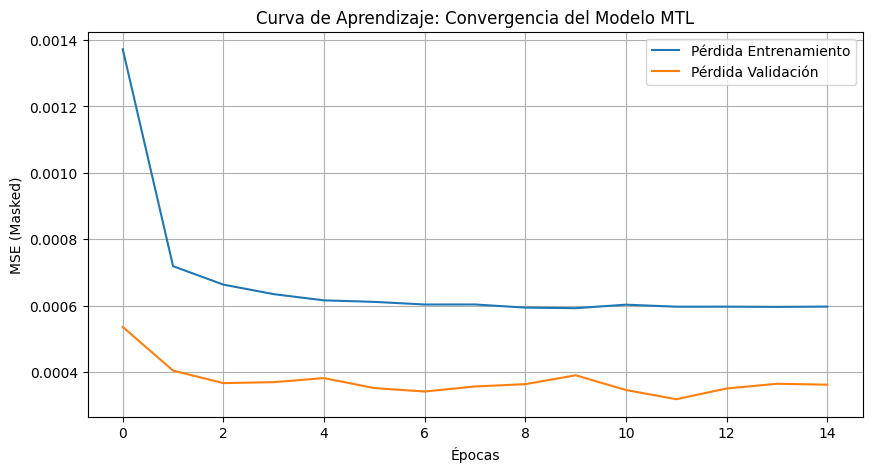

In [10]:
plt.figure(figsize=(10, 5))
# Graficamos el historial (si detuviste en la época 10, usa historial_train[:10])
plt.plot(historial_train, label='Pérdida Entrenamiento')
plt.plot(historial_val, label='Pérdida Validación')
plt.title("Curva de Aprendizaje: Convergencia del Modelo MTL")
plt.xlabel("Épocas")
plt.ylabel("MSE (Masked)")
plt.legend()
plt.grid(True)
plt.savefig("convergencia_mtl.png", dpi=300)
plt.show()

In [11]:
modelo_dl.eval()
with torch.no_grad():
    y_pred = modelo_dl(X_test_tensor.to(device)).cpu().numpy()
    y_true = Y_test_tensor.cpu().numpy()

# Creamos una máscara para ignorar los -1.0 en el cálculo del R2
mask = (y_true != -1.0)

resultados_r2 = {}
for i, cultivo in enumerate(cultivos):
    # Filtramos solo las parcelas donde SÍ hay cultivo real (usando la máscara)
    cultivo_mask = mask[:, i]
    score = r2_score(y_true[cultivo_mask, i], y_pred[cultivo_mask, i])
    resultados_r2[cultivo] = score

# Imprimimos resultados ordenados
print(f"{'Cultivo':<15} | {'R2 Score':<8}")
print("-" * 25)
for cultivo, score in sorted(resultados_r2.items(), key=lambda x: x[1], reverse=True):
    print(f"{cultivo:<15} | {score:.4f}")

Cultivo         | R2 Score
-------------------------
Walnuts         | 0.9832
Alfalfa         | 0.9797
Wheat           | 0.9642
Grapes          | 0.9551
Almonds         | 0.9492
Pistachios      | 0.9056
Cotton          | 0.8975
Strawberries    | 0.8817
Tomatoes        | 0.8734
Lettuce         | 0.8264
Oranges         | 0.7705
Rice            | 0.5195


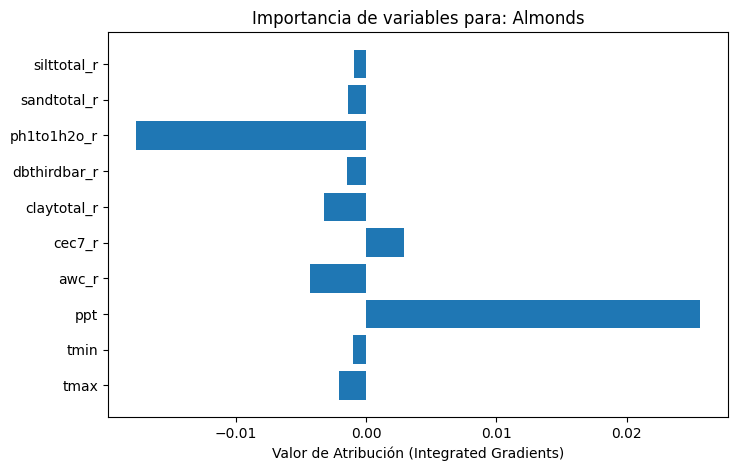

In [12]:
# 1. Elegimos un cultivo, por ejemplo, Walnuts (índice 0 según tu orden)
cultivo_idx = 0 
ig = IntegratedGradients(modelo_dl)

# 2. Analizamos una muestra (o el dataset completo si tu PC aguanta)
attributions = ig.attribute(X_test_tensor.to(device), target=cultivo_idx)

# 3. Agregamos las importancias para visualizar
importancia = attributions.mean(dim=0).cpu().detach().numpy()

# 4. Gráfico de barras de importancia
plt.figure(figsize=(8, 5))
plt.barh(variables_x, importancia)
plt.title(f"Importancia de variables para: {cultivos[cultivo_idx]}")
plt.xlabel("Valor de Atribución (Integrated Gradients)")
plt.show()

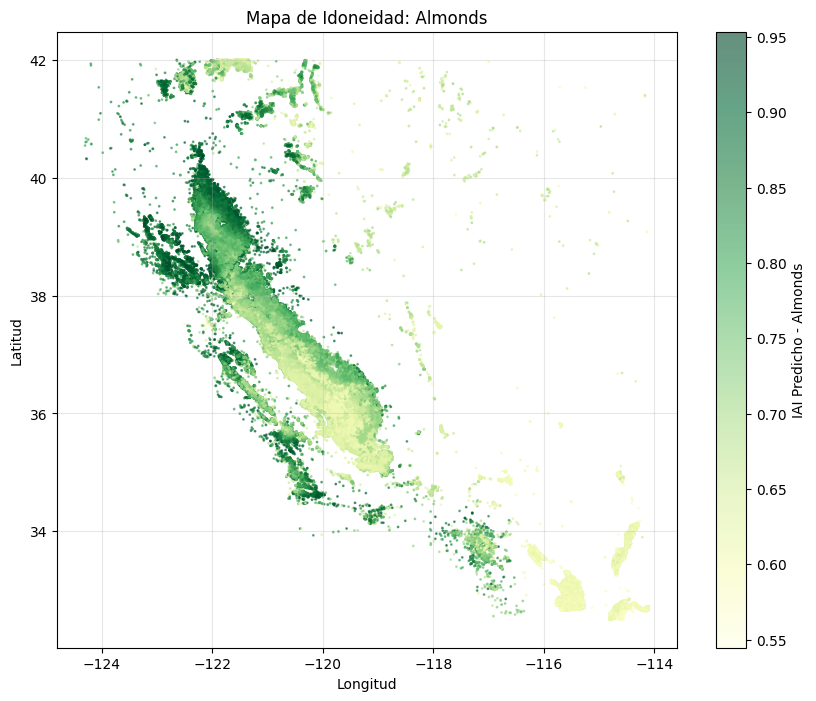

In [17]:
# VISUALIZACIÓN ESPACIAL...

# 1. Extraer las coordenadas del 'struct' de location
# Según tu imagen, la estructura es: {"Point", [lon, lat]}
df_mapa = df_wide.with_columns([
    pl.col("location").struct.field("coordinates").list.get(0).alias("lon"),
    pl.col("location").struct.field("coordinates").list.get(1).alias("lat")
])
# 2. Inferencia: Obtener predicciones para TODO el dataset
modelo_dl.eval()
with torch.no_grad():
    X_full = torch.tensor(scaler.transform(df_wide.select(variables_x).to_numpy()), dtype=torch.float32).to(device)
    predicciones = modelo_dl(X_full).cpu().numpy()

# 3. Unir predicciones al dataframe geográfico
# Creamos columnas con las predicciones para cada cultivo
for i, cultivo in enumerate(cultivos):
    df_mapa = df_mapa.with_columns(pl.Series(cultivo, predicciones[:, i]))

# 4. Graficar un ejemplo: Idoneidad para "Almonds"
# Puedes cambiar "Almonds" por cualquier otro cultivo de tu lista
cultivo_a_mapear = "Almonds"

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df_mapa["lon"], 
    df_mapa["lat"], 
    c=df_mapa[cultivo_a_mapear], 
    cmap="YlGn", # Escala de verde para idoneidad
    s=1, 
    alpha=0.6
)
plt.colorbar(sc, label=f"IAI Predicho - {cultivo_a_mapear}")
plt.title(f"Mapa de Idoneidad: {cultivo_a_mapear}")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Exportar para GIS (QGIS/ArcGIS)
df_mapa.write_parquet("../Data/mapa_idoneidad_final.parquet")


In [18]:
# Guardar el modelo entrenado
torch.save(modelo_dl.state_dict(), "../models/modelo_mtl_agro.pth")
